# Implementação da Arquitetura LeNet-5 em PyTorch

Este notebook apresenta uma implementação moderna da clássica rede neural **LeNet-5**, adaptada para o dataset MNIST utilizando a função de ativação **ReLU**.

### 1. Definição do Modelo e Imports

Aqui importamos as bibliotecas necessárias e definimos a classe `LeNet5`. Note que a estrutura do Extrator de Características (CNN) e do Classificador (FC) está claramente separada.

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        self.feature_extractor = nn.Sequential(            
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(),
            nn.Linear(in_features=84, out_features=num_classes),
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits

### 2. Visualização Inicial de Filtros

Antes do treinamento, os filtros da primeira camada contêm apenas ruído aleatório. Esta função nos permite visualizar como esses pesos evoluem.

In [3]:
def plot_filters(model, title='Filtros da Primeira Camada'):
    filters = model.feature_extractor[0].weight.data.cpu().numpy()
    num_filters = filters.shape[0]
    
    fig, axes = plt.subplots(1, num_filters, figsize=(15, 3))
    fig.suptitle(title, fontsize=16)
    
    for i in range(num_filters):
        f = filters[i, 0, :, :]
        f_min, f_max = f.min(), f.max()
        f = (f - f_min) / (f_max - f_min)
        
        axes[i].imshow(f, cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'Filtro {i+1}')
    
    plt.show()

### 3. Carregamento e Visualização do Dataset

Utilizamos o dataset MNIST oficial, aplicando normalização e transformando as imagens em tensores do PyTorch.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

def show_mnist_examples(dataset, num_images=10):
    fig, axes = plt.subplots(1, num_images, figsize=(20, 4))
    indices = np.random.choice(len(dataset), num_images, replace=False)
    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        axes[i].imshow(image.squeeze().numpy(), cmap='gray')
        axes[i].set_title(f'L: {label}')
        axes[i].axis('off')
    plt.show()

### 4. Visualização dos Feature Maps (Primeira Camada)

Esta célula captura a saída da primeira camada convolucional para uma imagem específica, mostrando o que a rede "enxerga" após aplicar seus filtros. Isso ajuda a entender como as características simples saão extraídas no início do processamento.

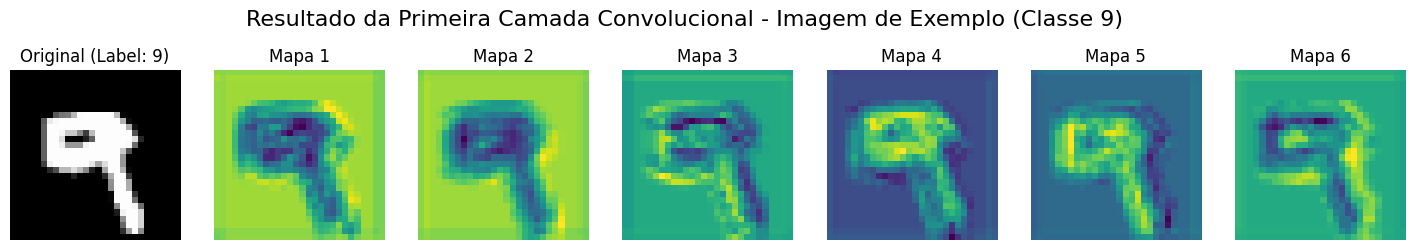

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)

def plot_feature_maps(model, image, label, device):
    model.eval()
    with torch.no_grad():
        # Passar a imagem apenas pela primeira sub-camada (Conv2d)
        first_conv_layer = model.feature_extractor[0]
        feature_maps = first_conv_layer(image.unsqueeze(0).to(device))
        
    feature_maps = feature_maps.squeeze(0).cpu().numpy()
    num_maps = feature_maps.shape[0]
    
    fig, axes = plt.subplots(1, num_maps + 1, figsize=(18, 3))
    
    # Mostrar imagem original com label
    axes[0].imshow(image.squeeze().numpy(), cmap='gray')
    axes[0].set_title(f'Original (Label: {label})')
    axes[0].axis('off')
    
    for i in range(num_maps):
        axes[i+1].imshow(feature_maps[i], cmap='viridis')
        axes[i+1].set_title(f'Mapa {i+1}')
        axes[i+1].axis('off')
        
    plt.suptitle(f"Resultado da Primeira Camada Convolucional - Imagem de Exemplo (Classe {label})", fontsize=16)
    plt.show()

# Pegar uma imagem aleatória e mostrar o processamento
idx = np.random.randint(len(test_dataset))
test_image, test_label = test_dataset[idx]
plot_feature_maps(model, test_image, test_label, device)

### 5. Ciclo de Treinamento

Configuramos o treinamento para rodar em GPU (se disponível) e utilizamos o otimizador **Adam**. Ao final, visualizamos como os filtros mudaram após aprenderem padrões.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Visualizando filtros antes do treinamento:")
plot_filters(model, title='Filtros ANTES do Treinamento')

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (i+1) % 200 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

print("Treinamento Concluído!")
print("Visualizando filtros depois do treinamento:")
plot_filters(model, title='Filtros DEPOIS do Treinamento')

### 6. Avaliação e Métricas Profissionais

Analisamos a performance do modelo no conjunto de teste através de uma **Matriz de Confusão** e visualizamos casos onde a rede cometeu erros.

Acurácia Global do Modelo no Conjunto de Teste: 98.72%


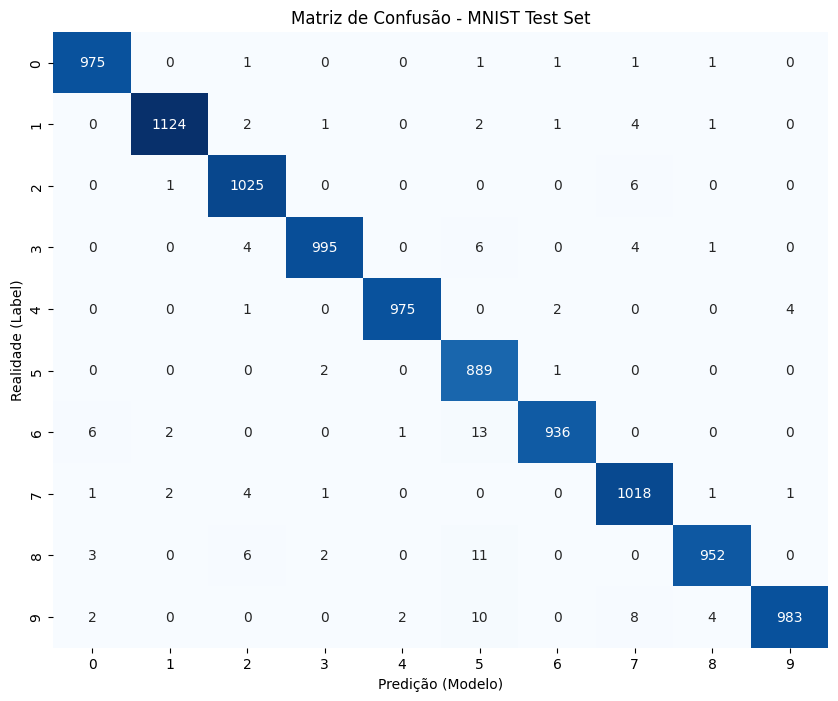


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.95      1.00      0.97       892
           6       0.99      0.98      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Exibindo 5 exemplos que a rede errou:


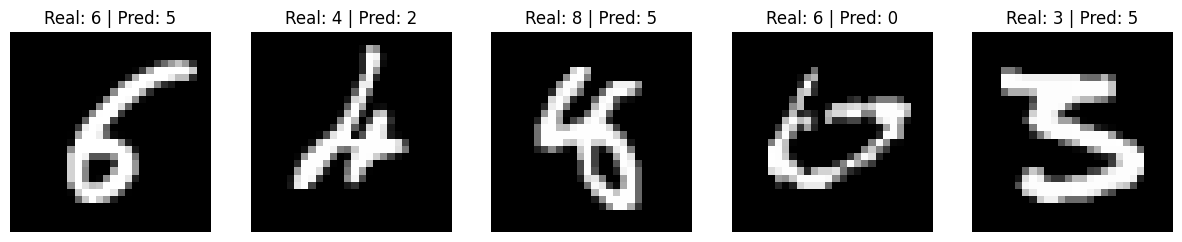

In [21]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Imprimir a % de acertos (Acurácia Global)
accuracy = accuracy_score(all_labels, all_preds)
print(f"Acurácia Global do Modelo no Conjunto de Teste: {accuracy * 100:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predição (Modelo)')
plt.ylabel('Realidade (Label)')
plt.title('Matriz de Confusão - MNIST Test Set')
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(all_labels, all_preds))

misclassified_idx = np.where(np.array(all_preds) != np.array(all_labels))[0]
if len(misclassified_idx) > 0:
    print(f"\nExibindo {min(5, len(misclassified_idx))} exemplos que a rede errou:")
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i in range(5):
        idx = misclassified_idx[i]
        img, label = test_dataset[idx]
        axes[i].imshow(img.squeeze().numpy(), cmap='gray')
        axes[i].set_title(f"Real: {label} | Pred: {all_preds[idx]}")
        axes[i].axis('off')
    plt.show()

### 7. Exportação do Modelo

Salvando o `state_dict` (pesos treinados) para que o modelo possa ser reutilizado em outras aplicações ou produção.

In [ ]:
import os

save_dir = 'models'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

model_path = os.path.join(save_dir, 'lenet5_mnist.pth')
torch.save(model.state_dict(), model_path)
print(f"Modelo salvo com sucesso em: {model_path}")

### 8. Carregamento e Inferência Rápida

Validando que o modelo pode ser recarregado do disco corretamente e testando uma predição instantânea.

Modelo carregado com sucesso de models/lenet5_mnist.pth!


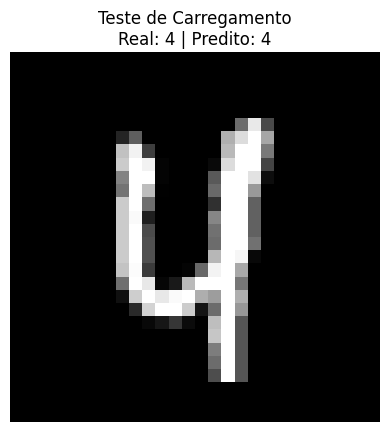

In [20]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Garantir que o dispositivo está definido
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_path = 'models/lenet5_mnist.pth'
if os.path.exists(model_path):
    # Instanciar a classe e carregar os pesos
    model = LeNet5()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    print(f"Modelo carregado com sucesso de {model_path}!")
    
    # Teste de inferência
    if 'test_dataset' in globals():
        random_idx = np.random.randint(len(test_dataset))
        image, label = test_dataset[random_idx]
        
        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))
            _, predicted = torch.max(output, 1)
            
        plt.imshow(image.squeeze().numpy(), cmap='gray')
        plt.title(f"Teste de Carregamento\nReal: {label} | Predito: {predicted.item()}")
        plt.axis('off')
        plt.show()
    else:
        print("test_dataset não encontrado. Por favor, execute a célula do Tópico 3.")
else:
    print(f"Arquivo {model_path} não encontrado.")
